# Experiment 03 — Reader-visible fit diagnostics

**Paper reference.** §2.2 'Empirical Results', Appendix B.2.

**Goal.** For each (scheme, policy), fit the Stage-2 selected linear model and produce three reader-facing plots: pred-vs-actual scatter, residual histogram, and a calibration-by-decile plot. These are the figures that anchor the linearity claim.

In [1]:
import os, sys, warnings
warnings.simplefilter('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
import negolin_v15 as nv
nv.setup_matplotlib()

DATA_DIR = 'merged_results'    # <-- edit if needed
OUT_DIR  = './out'
os.makedirs(OUT_DIR, exist_ok=True)

raw = nv.load_run_files(DATA_DIR)
_, turns = nv.preprocess_turns(raw)
POLICIES = list(nv.POLICIES)
SCHEMES  = list(nv.SCHEMES)
print(f'rows={len(turns):,}  policies={POLICIES}  schemes={SCHEMES}')

rows=45,779  policies=['PVD', 'IC', 'FRB', 'RFK', 'OADS', 'MEVJ']  schemes=['A', 'B', 'C', 'D']


In [2]:
# Load the Stage-2 selection produced by 02_main_sweep.ipynb
sel_path = Path(OUT_DIR) / 'selected_linear.csv'
if sel_path.exists():
    SELECTED = pd.read_csv(sel_path)
    print('Loaded selected_linear.csv:'); display(SELECTED.head())
else:
    # Sensible fallback: Feature II + Ridge per (scheme, policy)
    rows = [{'scheme': s, 'policy': p, 'chosen_family': 'II', 'chosen_model': 'Ridge'}
            for s in SCHEMES for p in POLICIES]
    SELECTED = pd.DataFrame(rows)
    print('selected_linear.csv not found -> using fallback (II/Ridge)')

def picked(scheme, policy):
    r = SELECTED.set_index(['scheme','policy']).loc[(scheme, policy)]
    fam = r['chosen_family']
    if fam == 'Base': fam = 'II'    # Base isn't a feature spec -- fall back
    return fam, r['chosen_model']

Loaded selected_linear.csv:


,scheme,policy,best_family,best_model,best_mae,best_mae$,chosen_family,chosen_model,chosen_dim_phi,chosen_tau,chosen_theta_l1,chosen_mae,chosen_mae$,gap_rel
0,A,FRB,VII,GBR,0.695431,333.803356,VII,GBR,7,2,NaN,0.695431,333.803356,0.000000
1,A,IC,IV,GBR,0.575605,386.213163,IV,GBR,6,1,NaN,0.575605,386.213163,0.000000
2,A,MEVJ,V,GBR,0.405730,447.059539,V,GBR,3,1,NaN,0.405730,447.059539,0.000000
3,A,OADS,VII,GBR,0.664666,375.987772,VII,GBR,7,2,NaN,0.664666,375.987772,0.000000
4,A,PVD,IV,GBR,0.366437,418.193682,V,OLS,3,1,0.722564,0.389880,562.509689,0.063976


## 1. Fit OOF predictions for every (scheme, policy)

In [4]:
OOF = {}
for sch in SCHEMES:
    print(sch)
    for pol in POLICIES:
        print("   ", pol)
        fam, mdl = picked(sch, pol)
        sub = turns.query('scheme == @sch and policy == @pol')
        meta, X, y, _ = nv.build_design_matrix(sub, fam)
        (_, _, _), (m_n, X_n, y_n) = nv.partition_persist(meta, X, y)
        pred, _ = nv.grouped_cv_predict(m_n, X_n, y_n, mdl)
        OOF[(sch, pol)] = pred
print('done; cells:', len(OOF))

A
    PVD
    IC
    FRB
    RFK
    OADS
    MEVJ
B
    PVD
    IC
    FRB
    RFK
    OADS
    MEVJ
C
    PVD
    IC
    FRB
    RFK
    OADS
    MEVJ
D
    PVD
    IC
    FRB
    RFK
    OADS
    MEVJ
done; cells: 24


## 2. Pred-vs-actual scatter (one panel per cell, faceted by scheme)

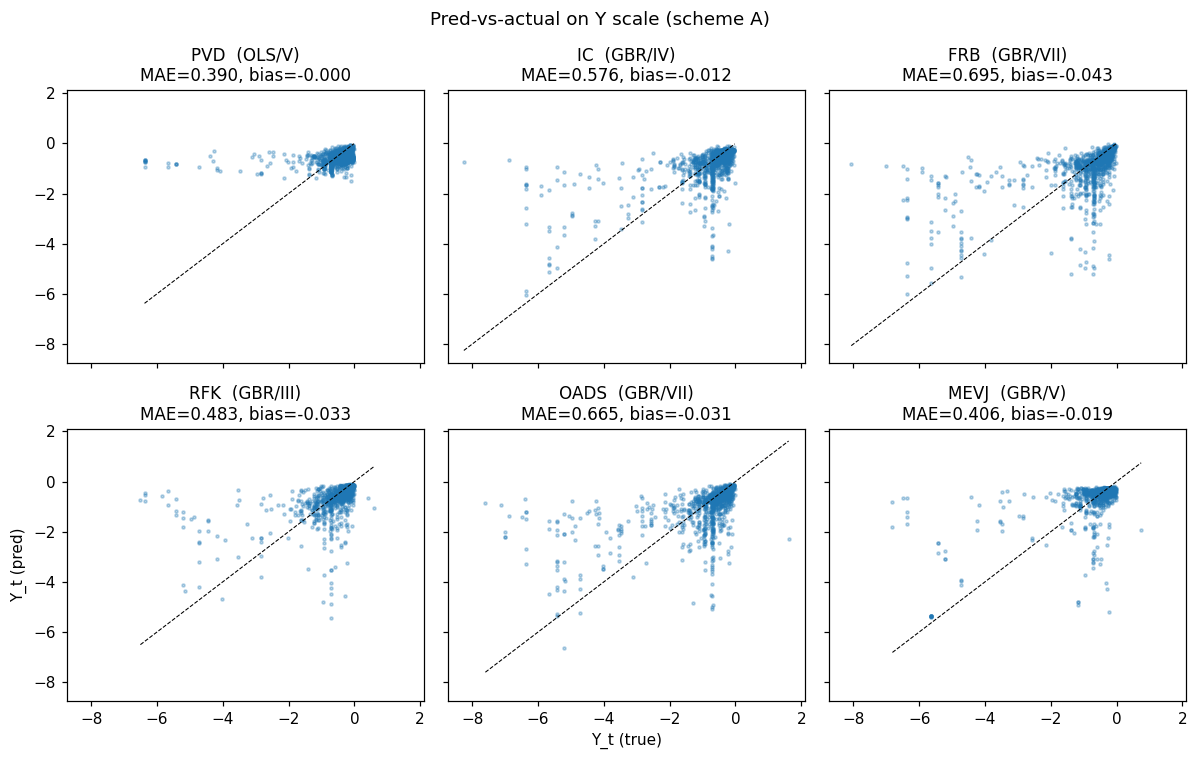

In [5]:
# Pick a single scheme to focus on; rest are saved
FOCUS = 'A'
fig, axes = plt.subplots(2, 3, figsize=(11, 7), sharex=True, sharey=True)
for ax, pol in zip(axes.ravel(), POLICIES):
    pred = OOF[(FOCUS, pol)]
    ax.scatter(pred['y_true'], pred['y_pred'], s=4, alpha=0.3)
    lo, hi = pred[['y_true','y_pred']].min().min(), pred[['y_true','y_pred']].max().max()
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
    m = nv.cv_metrics(pred)
    fam, mdl = picked(FOCUS, pol)
    ax.set_title(f'{pol}  ({mdl}/{fam})\nMAE={m["mae"]:.3f}, bias={m["bias"]:+.3f}')
axes[1,1].set_xlabel('Y_t (true)'); axes[1,0].set_ylabel('Y_t (pred)')
fig.suptitle(f'Pred-vs-actual on Y scale (scheme {FOCUS})')
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'fig_exp03_pred_vs_actual_{FOCUS}.png'))
plt.show()

## 3. Residual histogram by policy (pooled across schemes)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=True)
for ax, pol in zip(axes.ravel(), POLICIES):
    parts = [OOF[(s, pol)].assign(scheme=s) for s in SCHEMES]
    df = pd.concat(parts, ignore_index=True)
    res = df['y_pred'] - df['y_true']
    ax.hist(res, bins=60)
    ax.axvline(0, color='k', lw=0.7)
    ax.axvline(res.mean(), color='red', ls='--', lw=0.7,
               label=f'mean={res.mean():+.3f}')
    ax.set_title(pol); ax.legend()
axes[1,1].set_xlabel('residual = Ŷ_t − Y_t')
fig.suptitle('Residual histograms (pooled across schemes)')
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_exp03_residual_hist.png'))
plt.show()

## 4. Calibration: predicted vs realised within deciles of Ŷ_t

In [ ]:
def calibration_table(pred, n_dec=10):
    d = pred.copy()
    d['dec'] = pd.qcut(d['y_pred'], n_dec, labels=False, duplicates='drop')
    return d.groupby('dec').agg(mean_pred=('y_pred','mean'),
                                mean_true=('y_true','mean'),
                                n=('y_true','size')).reset_index()

fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=True)
for ax, pol in zip(axes.ravel(), POLICIES):
    parts = [OOF[(s, pol)] for s in SCHEMES]
    df = pd.concat(parts, ignore_index=True)
    cal = calibration_table(df, n_dec=10)
    ax.plot(cal['mean_pred'], cal['mean_true'], 'o-')
    lo = float(min(cal[['mean_pred','mean_true']].min()))
    hi = float(max(cal[['mean_pred','mean_true']].max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
    ax.set_title(pol)
axes[1,1].set_xlabel('mean Ŷ_t in decile'); axes[1,0].set_ylabel('mean Y_t in decile')
fig.suptitle('Calibration by Y_t decile (pooled across schemes)')
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_exp03_calibration.png'))
plt.show()

If decile means hug the diagonal, the linear model is well-calibrated; systematic deviation in any decile flags a regime where the linear policy mis-fits.